# Snekmer `easy` Tutorial

**`snekmer easy`** is a streamlined front-end for the Learn/Apply pipeline.  
It takes your training sequences, query sequences, and annotation info and handles the rest.

This tutorial uses the demo data included in the Snekmer repository and runs entirely from the command line.

---

**When to use `easy` vs. `snekmer learn` / `snekmer apply` directly:**

| Situation | Recommendation |
|---|---|
| First time running, want results fast | `easy` |
| Existing `config.yaml` and directory setup | `snekmer learn` then `snekmer apply` |
| Adding new training data to an existing model | `snekmer learn` then `snekmer apply` |
| Exploring parameters interactively | `easy` wizard |

## Setup

Install Snekmer and activate your environment before running this notebook.  
See the [installation guide](https://snekmer.readthedocs.io/en/latest/getting_started/install.html) for details.

To use Snekmer inside a Jupyter notebook kernel:

```bash
source ~/snekmer_env/bin/activate
pip install ipykernel
python -m ipykernel install --user --name=snekmer
jupyter notebook
```

> **Note:** This notebook assumes you are running it from the `docs/source/tutorial/` directory.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Paths to demo data (relative to docs/source/tutorial/)
DEMO_ROOT    = Path("../../../resources/demo_sequences/learn_apply_inputs")
train_dir    = DEMO_ROOT / "learn"
query_file   = DEMO_ROOT / "apply" / "test_sequences_1.fasta"
ann_file     = DEMO_ROOT / "annotations" / "TIGRFAMs_annotation.ann"
output_dir   = Path("easy_output")
results_path = output_dir / "apply" / "snekmer_results.csv"

In [2]:
!snekmer --version

1.4.1


## What `easy` needs

`easy` requires three inputs:

| Input | Flag | Description |
|---|---|---|
| Training sequences | `--train` | FASTA file **or** directory of FASTA files with known annotations |
| Query sequences | `--query` | FASTA file **or** directory of FASTA files to annotate |
| Annotations | `--ann` | Path to a `.ann` file (TSV: `id` \t `family`) |
| *(or)* | `--create-ann` | Auto-generate annotations from training FASTA headers (see below) |

### Annotation file format (`.ann`)

A tab-separated file with two columns: `id` and `family`:

```
id              family
A0A2D0MWR0      TIGR04183
A0A2D0MY79      TIGR04131
A0A1Y4R5C6      TIGR00722
```

The `id` must match the accession in your FASTA headers.  
For UniProt-style headers (`>db|ACCESSION|name ...`), Snekmer extracts the field **between the first pair of `|` characters**.

### Auto-generating annotations with `--create-ann`

If your training FASTA headers encode the family label between pipes, you can skip the `.ann` file:

```
>db|FAMILY_LABEL|seqid description
```

Use `--create-ann` and Snekmer will parse the headers and build the annotation file for you.

## Demo data

The demo data is included in the Snekmer repository under `resources/demo_sequences/learn_apply_inputs/`:

```
resources/demo_sequences/learn_apply_inputs/
├── learn/                       ← 10 training FASTA files (5,000 annotated proteins, 200 TIGRFAM families)
│   ├── training_sequences_1.fasta
│   ├── ...
│   └── training_sequences_10.fasta
├── apply/                       ← 1 query FASTA (3,000 proteins: in-family, other families, unannotated)
│   └── test_sequences_1.fasta
└── annotations/
    └── TIGRFAMs_annotation.ann  ← id/family TSV
```

In [3]:
%%bash
DEMO=../../../resources/demo_sequences/learn_apply_inputs
for f in "$DEMO/learn" \
         "$DEMO/apply/test_sequences_1.fasta" \
         "$DEMO/annotations/TIGRFAMs_annotation.ann"; do
    [ -e "$f" ] && echo "Available: $f" || echo "MISSING:   $f"
done

Available: ../../../resources/demo_sequences/learn_apply_inputs/learn
Available: ../../../resources/demo_sequences/learn_apply_inputs/apply/test_sequences_1.fasta
Available: ../../../resources/demo_sequences/learn_apply_inputs/annotations/TIGRFAMs_annotation.ann


## Running `easy`

The command below runs the full pipeline non-interactively. All required inputs are provided as flags, so no prompts will appear.

```bash
snekmer easy \
    --train  <training FASTA or directory> \
    --query  <query FASTA or directory> \
    --ann    <path/to/annotations.ann> \
    --output <output directory>
```

All other parameters (k-mer length, alphabet, etc.) have sensible defaults and do not need to be specified for most analyses.

In [4]:
%%bash
export MPLBACKEND=agg
# This is the command line call:
snekmer easy \
    --train  ../../../resources/demo_sequences/learn_apply_inputs/learn \
    --query  ../../../resources/demo_sequences/learn_apply_inputs/apply/test_sequences_1.fasta \
    --ann    ../../../resources/demo_sequences/learn_apply_inputs/annotations/TIGRFAMs_annotation.ann \
    --output easy_output

Assuming unrestricted shared filesystem usage.
host: WE47199
Building DAG of jobs...
Using shell: /bin/bash
Provided cores: 10
Rules claiming more threads will be scaled down.
Job stats:
job                          count
-------------------------  -------
all                              1
copy_results_for_apply           1
eval_apply_reverse_seqs         10
eval_apply_sequences            10
evaluate                         1
learn                           10
learn_report                     1
merge                            1
reverse_decoy_evaluations        1
total                           36

Select jobs to execute...
Execute 10 jobs...

[Fri May  1 13:29:41 2026]
Job 16: Building kmer-association matrix from output/vector/vector/training_sequences_2.npz. Output written to output/learn/kmer_counts_training_sequences_2.csv.
Reason: Code has changed since last execution
[Fri May  1 13:29:41 2026]
Job 20: Building kmer-association matrix from output/vector/vector/training_sequence

Dataframes merged: 1 out of 10
Dataframes merged: 2 out of 10
Dataframes merged: 3 out of 10
Dataframes merged: 4 out of 10
Dataframes merged: 5 out of 10
Dataframes merged: 6 out of 10
Dataframes merged: 7 out of 10
Dataframes merged: 8 out of 10
Dataframes merged: 9 out of 10
Dataframes merged: 10 out of 10

Checking for base file to merge with.

No file type detected. Please use a .csv file in input/base directory.


Database Merged. Not merged with base file.



[Fri May  1 13:29:57 2026]
Finished jobid: 21 (Rule: merge)
11 of 36 steps (31%) done
Select jobs to execute...
Execute 20 jobs...

[Fri May  1 13:29:57 2026]
Job 38: Using Apply to test reversed (decoy) sequences in output/vector/vector/training_sequences_6.npz. Output written to output/evaluate/eval_apply_reversed/seq_annotation_scores_training_sequences_6.csv.gz.
Reason: Input files updated by another job: output/learn/kmer_counts_total.csv
[Fri May  1 13:29:57 2026]
Job 41: Using Apply to test reversed (decoy) sequences in output/vector/vector/training_sequences_9.npz. Output written to output/evaluate/eval_apply_reversed/seq_annotation_scores_training_sequences_9.csv.gz.
Reason: Input files updated by another job: output/learn/kmer_counts_total.csv
[Fri May  1 13:29:57 2026]
Job 30: Using Apply to test normal sequences in output/vector/vector/training_sequences_8.npz. Output written to output/evaluate/eval_apply_sequences/seq_annotation_scores_training_sequences_8.csv.gz.
Reason: 

Base confidence file not found or multiple files present. Only one file is allowed in baseConfidence.


[Fri May  1 13:30:25 2026]
Finished jobid: 43 (Rule: evaluate)
33 of 36 steps (92%) done
Select jobs to execute...
Execute 2 jobs...

[Fri May  1 13:30:25 2026]
Job 45: Generating full Snekmer Learn Report at output/Snekmer_Learn_Report.html
Reason: Input files updated by another job: output/learn/kmer_counts_training_sequences_7.csv, output/learn/kmer_counts_training_sequences_2.csv, output/learn/kmer_counts_training_sequences_5.csv, output/learn/kmer_counts_training_sequences_4.csv, output/learn/kmer_counts_training_sequences_3.csv, output/eval_conf/global_confidence_scores.csv, output/learn/kmer_counts_training_sequences_8.csv, output/learn/kmer_counts_training_sequences_10.csv, output/eval_conf/family_summary_stats.csv, output/learn/kmer_counts_training_sequences_1.csv, output/learn/kmer_counts_training_sequences_6.csv, output/eval_conf/family_stats_checkpoint.csv, output/learn/kmer_counts_total.csv, output/learn/kmer_counts_training_sequences_9.csv
[Fri May  1 13:30:25 2026]
Job 4


--- Running snekmer learn ---

Copying learn outputs to apply input directories...

--- Running snekmer apply ---

=== Complete ===
Results: /Users/jaco059/OneDrive - PNNL/Desktop/Snekmer_New_laptop_rename/PRE_PAPER_PRS/Snekmer/docs/source/tutorial/easy_learn_apply_output/apply/snekmer_results.csv


## Output structure

After running, the output directory contains two sub-workspaces:

```
easy_output/
├── learn/                  ← Learn pipeline workspace
│   ├── input/              ← symlinks to training FASTA files
│   ├── annotations/        ← your .ann file
│   ├── config.yaml         ← generated config
│   ├── apply_inputs/       ← handoff files for apply
│   │   ├── counts/kmer_counts_total.csv
│   │   ├── stats/family_summary_stats.csv
│   │   └── confidence/global_confidence_scores.csv
│   └── output/
│       ├── learn/          ← per-file and total kmer count matrices
│       └── eval_conf/      ← confidence scores and family stats
│
└── apply/                  ← Apply pipeline workspace
    ├── input/              ← symlinks to query FASTA files
    ├── counts/             ← kmer_counts_total.csv (copied from learn)
    ├── confidence/         ← global_confidence_scores.csv (copied from learn)
    ├── stats/              ← family_summary_stats.csv (copied from learn)
    ├── config.yaml         ← generated config
    ├── snekmer_results.csv ← main results file
    └── output/
        └── apply/          ← per-file kmer_summary CSVs
```

**The main results file** is `apply/snekmer_results.csv`.

## Reading the results

The results file contains one row per query sequence with five columns:

| Column | Description |
|---|---|
| `Sequence` | Sequence identifier from the FASTA header |
| `Prediction` | Predicted family (highest cosine similarity) |
| `Score` | Cosine similarity between the sequence and the predicted family |
| `delta` | Gap between top and second-best similarity scores |
| `Confidence` | Calibrated probability the prediction is correct (0–1) |

In [5]:
df = pd.read_csv(results_path)
print(f"Total sequences: {len(df)}")
df.head(10)

Total sequences: 3000


,Sequence,Prediction,Score,delta,Confidence
0,tr|A0A2S8EUS7|A0A2S8EUS7_9RHOB,TIGR01783,0.199116,0.00,0.383333
1,tr|A0A401ZGP4|A0A401ZGP4_9CHLR,TIGR00757,0.315537,0.02,0.921569
2,tr|A0A427BXE3|A0A427BXE3_9GAMM,TIGR01023,0.198284,0.08,1.000000
3,tr|J2LWC9|J2LWC9_9BURK,TIGR00797,0.210697,0.00,0.383333
4,tr|A0A2Z5TEJ7|A0A2Z5TEJ7_9GAMM,TIGR00229,0.225655,0.00,0.383333
5,tr|A0A6G7WF57|A0A6G7WF57_9LACT,TIGR03534,0.297106,0.08,1.000000
6,tr|A0A1I1XLP5|A0A1I1XLP5_9FIRM,TIGR00229,0.265441,0.02,0.921569
7,tr|A0A0K8J9U8|A0A0K8J9U8_9FIRM,TIGR00231,0.225392,0.01,0.654545
8,tr|A0A0D8ZMS0|A0A0D8ZMS0_9CYAN,TIGR00496,0.169543,0.01,0.654545
9,tr|R7F3B1|R7F3B1_9BACT,TIGR01733,0.229176,0.00,0.383333


## Filtering by confidence

A **Confidence ≥ 0.95** threshold is a reasonable starting point for high-reliability annotations.  
For exploratory work you may lower this; for publication-quality calls you may want to raise it.

> **Note:** All sequences receive a prediction. Sequences with `Score = 0.0` have no overlapping k-mers with any training family; these predictions are not meaningful and should be excluded.

In [6]:
CONF_THRESHOLD = 0.95

high_conf = df[(df["Confidence"] >= CONF_THRESHOLD) & (df["Score"] > 0)].copy()
print(f"High-confidence predictions (\u2265{CONF_THRESHOLD}): {len(high_conf)} / {len(df)}")
high_conf.head(10)

High-confidence predictions (≥0.95): 995 / 3000


,Sequence,Prediction,Score,delta,Confidence
2,tr|A0A427BXE3|A0A427BXE3_9GAMM,TIGR01023,0.198284,0.08,1.000000
5,tr|A0A6G7WF57|A0A6G7WF57_9LACT,TIGR03534,0.297106,0.08,1.000000
10,tr|C5RAN2|C5RAN2_WEIPA,TIGR01017,0.290899,0.11,1.000000
11,tr|A0A2P1NPL9|A0A2P1NPL9_9BURK,TIGR00593,0.477110,0.14,1.000000
14,tr|A0A1Y0FXC9|A0A1Y0FXC9_9GAMM,TIGR00350,0.166781,0.03,0.956522
15,tr|A0A6P1ZCD6|A0A6P1ZCD6_9DELT,TIGR02937,0.207365,0.03,0.956522
17,tr|A0A3A9ZRN3|A0A3A9ZRN3_9ACTN,TIGR00594,0.405080,0.06,0.990991
20,tr|A8FCF0|A8FCF0_BACP2,TIGR00254,0.366038,0.05,1.000000
22,tr|A0A0N0KF67|A0A0N0KF67_9SPHN,TIGR00674,0.351895,0.15,1.000000
29,tr|A0A2S1LEL5|A0A2S1LEL5_9FLAO,TIGR00435,0.310315,0.05,1.000000


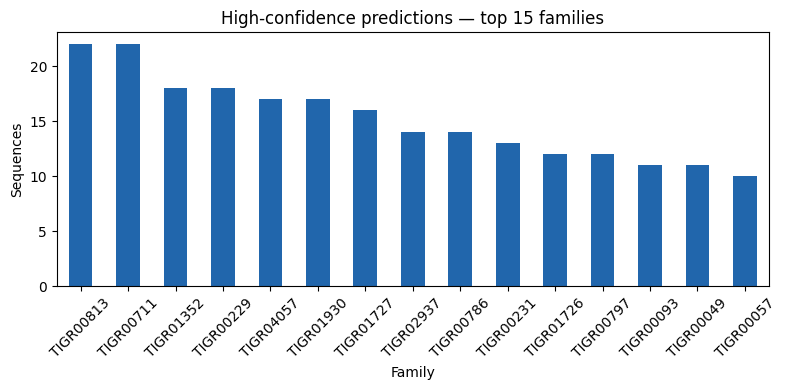

In [7]:
top_families = high_conf["Prediction"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 4))
top_families.plot(kind="bar", ax=ax, color="#2166ac")
ax.set_title("High-confidence predictions \u2014 top 15 families")
ax.set_xlabel("Family")
ax.set_ylabel("Sequences")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Post-hoc evaluation

When ground-truth annotations are available (as they are for this demo dataset), we can assess
prediction quality by comparing Snekmer's output against the known family labels.

The demo test set contains 3,000 proteins split across three groups:
- **In-family**: proteins from TIGRFAM families present in the training set
- **Other annotated**: proteins from families *not* in the training set
- **Unannotated**: proteins with no known family assignment

Because this demo uses a small training set (200 families, 5,000 sequences), accuracy here
represents a lower bound. Performance improves substantially with larger training sets.

> **Note:** All sequences receive a prediction regardless of confidence. Adjust `conf_cutoff`,
> `score_cutoff`, and `delta_cutoff` below to explore the precision/recall tradeoff.

Kept: 995/3000  |  TP:773 FP:87 FK:1140  |  Precision:0.899 Recall:0.404


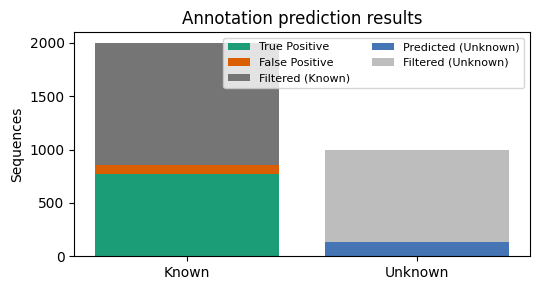

In [8]:
conf_cutoff, score_cutoff, delta_cutoff = CONF_THRESHOLD, None, None

edf = pd.read_csv(results_path)
edf.columns = edf.columns.str.strip().str.capitalize()
edf["Accession"] = edf["Sequence"].str.split("|").str[1].fillna(edf["Sequence"])
ann_gt = pd.read_csv(
    DEMO_ROOT / "annotations" / "TIGRFAMs_annotation.ann",
    sep="\t",
).rename(columns={"id": "Accession", "family": "Truefamily"})
edf = edf.merge(ann_gt, on="Accession", how="left")

kept = pd.Series(True, index=edf.index)
for col, cut in [("Confidence", conf_cutoff), ("Score", score_cutoff), ("Delta", delta_cutoff)]:
    if cut is not None:
        kept &= edf[col] >= cut

known = edf["Truefamily"].notna()
corr  = known & (edf["Prediction"] == edf["Truefamily"])
counts = {
    "True Positive":       int((kept & corr).sum()),
    "False Positive":      int((kept & known & ~corr).sum()),
    "Filtered (Known)":    int((~kept & known).sum()),
    "Predicted (Unknown)": int((~known & kept).sum()),
    "Filtered (Unknown)":  int((~known & ~kept).sum()),
}
TP, FP, FK = counts["True Positive"], counts["False Positive"], counts["Filtered (Known)"]
prec = TP / (TP + FP) if TP + FP else float("nan")
rec  = TP / (TP + FK) if TP + FK else float("nan")
print(f"Kept: {kept.sum()}/{len(edf)}  |  TP:{TP} FP:{FP} FK:{FK}  |  Precision:{prec:.3f} Recall:{rec:.3f}")

colors = {
    "True Positive":       "#1b9e77",
    "False Positive":      "#d95f02",
    "Filtered (Known)":    "#757575",
    "Predicted (Unknown)": "#4575b4",
    "Filtered (Unknown)":  "#bdbdbd",
}
fig, ax = plt.subplots(figsize=(5.5, 3))
for group, keys in [("Known",   ["True Positive", "False Positive", "Filtered (Known)"]),
                    ("Unknown", ["Predicted (Unknown)", "Filtered (Unknown)"])]:
    bot = 0
    for k in keys:
        ax.bar(group, counts[k], bottom=bot, color=colors[k], label=k)
        bot += counts[k]
ax.set(title="Annotation prediction results", ylabel="Sequences")
h, l = ax.get_legend_handles_labels()
ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Interactive mode (wizard)

If you omit `--train`, `--query`, or the annotation flag, `easy` enters an interactive wizard that prompts for each missing input:

```
$ snekmer easy

=== Snekmer easy ===

Step 1  Training sequences (file or directory path): /path/to/train/

Step 2  Query sequences (file or directory path): /path/to/query.fasta
  Found 10 training file(s), 1 query file(s).

Step 3  How are your training sequences annotated?

  [1] Family labels are embedded in FASTA headers (between | | characters)
      Example:  >db|TIGR04183|seqid Description text
                       ^^^^^^^^
                 this field becomes the family label
      (equivalent to passing --create-ann)

  [2] I have a separate annotation file (.ann)
      Format: tab-separated with columns: id  family
      (equivalent to passing --ann <path>)

  Choice [1]: 2

  Path to annotation file (.ann): /path/to/annotations.ann

Step 4  Output directory [snekmer_easy_output]: my_results
```

You can mix flags and wizard — for example, provide `--train` and `--ann` but omit `--query`, and only the query prompt will appear.

## Key parameters

Run `snekmer easy --help` to see all options. The most commonly adjusted:

| Flag | Default | Description |
|---|---|---|
| `--k` | `8` | K-mer length |
| `--alphabet` | `2` (solvacc) | Amino acid reduction alphabet (0–5 or name, see `--help`) |
| `--selection` | `top_hit` | Annotation selection method: `top_hit`, `greatest_distance`, `combined_distance` |
| `--threshold` | `Median` | Score threshold column from family stats: `Median`, `Mean`, `90th Percentile`, `None` |
| `--apply-output` | `snekmer_results.csv` | Output filename for the results CSV |
| `--cores` | all CPUs | Number of CPU cores to use |
| `--dry-run` | — | Show the pipeline steps without running them |

For advanced use (adding to an existing model, fragmentation, etc.), use `snekmer learn` and `snekmer apply` directly with a `config.yaml`.

In [9]:
!snekmer easy --help

usage: snekmer easy-learn-apply [options]

Guided front-end that runs learn then apply end-to-end.

Prompts for training sequences, query sequences, and annotation style,
then builds a self-contained workspace and runs both pipeline steps.
All prompts can be skipped by supplying the corresponding flags.

options:
  -h, --help            show this help message and exit

Input / output:
  --train PATH          Path to training sequences (FASTA file or directory of
                        FASTA files). If omitted, the wizard will prompt for
                        it. (default: None)
  --query PATH          Path to query sequences to annotate (FASTA file or
                        directory). If omitted, the wizard will prompt for it.
                        (default: None)
  --output DIR          Output directory for the workspace. If omitted, the
                        wizard will prompt. (default: None)

Annotation (choose one):
  --ann PATH            Path to an existing annotation f